In [1]:
!pip3 install -Uq pymcel nbformat

In [2]:
import pymcel as pc
from pymcel import constantes as const
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.integrate import solve_ivp

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


# Unidades

In [3]:
# Trabajaremos en unidades electromagnéticas absolutas, serán las Gaussianas

In [4]:
eps0 = const.eps0
UL = 1e6
UM = const.m_e
UT = UL / const.c

UV = UL / UT
UA = UL / UT**2
UF = UM * UL / UT**2

# Carga
UQ = UL * np.sqrt(4 * np.pi * eps0 * UF)
UE = UF / UQ
UB = UE / UV 

C = 1

## Tensor de Faraday

In [5]:
def tensor_faraday(B0):
    Ex = Ey = Ez = 0
    Bx = By = 0
    Bz = B0
    F = np.array([
        [0, -Ex, -Ey, -Ez],
        [Ex, 0, -Bz, By],
        [Ey, Bz, 0, -Bx],
        [Ez, -By, Bx, 0]
    ])
    return F

In [6]:
tensor_faraday(1)

array([[ 0,  0,  0,  0],
       [ 0,  0, -1,  0],
       [ 0,  1,  0,  0],
       [ 0,  0,  0,  0]])

## Ecuación de movimiento de una carga eléctrica

In [7]:
def edm_relativista(tau, Ys, B0, m, q):
    x0, x1, x2, x3, U0, U1, U2, U3 = Ys

    dx0_dtau = U0
    dx1_dtau = U1
    dx2_dtau = U2
    dx3_dtau = U3

    F = tensor_faraday(B0)

    Usub = np.array([U0, U1, U2, U3])
    f = (q / C) * F @ Usub

    dU0_dtau = f[0] / m
    dU1_dtau = f[1] / m
    dU2_dtau = f[2] / m
    dU3_dtau = f[3] / m

    return np.array([dx0_dtau, dx1_dtau, dx2_dtau, dx3_dtau,
                     dU0_dtau, dU1_dtau, dU2_dtau, dU3_dtau])

In [8]:
edm_relativista(0, [0, 0, 0, 0, 0, 1, 1, 1], 1, 1, 1)

array([ 0.,  1.,  1.,  1.,  0., -1.,  1.,  0.])

## Condiciones iniciales

In [9]:
t0 = 0

B0 = 1
q = 1
m = 1

r0 = np.array([1, 0, 0])
v0 = np.array([0, 0.5, 0.5])

x0 = np.array([C*t0, r0[0], r0[1], r0[2]])

gamma0 = 1 / np.sqrt(1 - np.linalg.norm(v0)**2 / C**2)
U0 = np.array([gamma0 * C, gamma0 * v0[0], gamma0 * v0[1], gamma0 * v0[2]])

# Cond init
Ys0 = np.concatenate((x0, U0))

In [10]:
taus = np.linspace(0, 10, 1000)
sol = solve_ivp(edm_relativista, (taus[0], taus[-1]), Ys0, args=(B0, q, m), t_eval=taus, method='Radau')

(np.float64(-0.4848049382403933),
 np.float64(1.0707049970590663),
 np.float64(-0.7778908965999443),
 np.float64(0.7778894495288221))

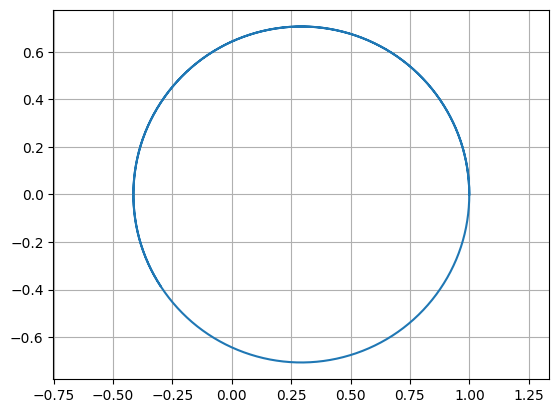

In [11]:
ts = sol.y[0]/C
xs = sol.y[1]
ys = sol.y[2]
zs = sol.y[3]

plt.plot(xs, ys)
plt.grid()
plt.axis('equal')

In [14]:
# Grafico 3D de la trayectoria: intento con Plotly y fallback a Matplotlib
import plotly.io as pio
# Preferir renderers interactivos en notebooks; ajustar si es necesario
try:
    pio.renderers.default = 'notebook_connected'
except Exception:
    pass
fig = go.Figure(data=go.Scatter3d(x=xs, y=ys, z=zs, mode='lines',
                                     line=dict(width=4, color='blue')))
fig.update_layout(title='Trayectoria 3D', width=900, height=700,
                  scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z',
                             aspectmode='auto'))
# Intentar mostrar con Plotly; si falla, dibujar con Matplotlib 3D
try:
    fig.show()
except Exception as e:
    print('Plotly display falló:', e)
    from mpl_toolkits.mplot3d import Axes3D
    figm = plt.figure(figsize=(9,7))
    ax = figm.add_subplot(111, projection='3d')
    ax.plot(xs, ys, zs, color='blue', linewidth=2)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    plt.show()